<a href="https://colab.research.google.com/github/mayurda8/TradeGuardian-AI/blob/main/TradeGuardian%20AI%3A%20Supply%20Chain%20Risk%20Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Intelligent Global Procurement Risk & Supply Chain Intelligence Platform

In [2]:
# Step 1 - Install Required Libraries
!pip -q install pandas numpy matplotlib seaborn plotly scikit-learn xgboost lightgbm shap pycountry requests tqdm openpyxl

In [3]:
#Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import requests
import json

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

print("="*60)
print("TradeGuardian AI Environment Ready")
print("="*60)

TradeGuardian AI Environment Ready


In [4]:
#Create Project Configuration
PROJECT_NAME = "TradeGuardian AI"

DATA_PATH = "data/raw/"
PROCESSED_PATH = "data/processed/"
MODEL_PATH = "models/"
REPORT_PATH = "reports/"
FIGURE_PATH = "figures/"

RANDOM_STATE = 42

print("="*60)
print(PROJECT_NAME)
print("="*60)

print(f"Data Path       : {DATA_PATH}")
print(f"Processed Data  : {PROCESSED_PATH}")
print(f"Models          : {MODEL_PATH}")
print(f"Reports         : {REPORT_PATH}")
print(f"Figures         : {FIGURE_PATH}")
print(f"Random Seed     : {RANDOM_STATE}")

TradeGuardian AI
Data Path       : data/raw/
Processed Data  : data/processed/
Models          : models/
Reports         : reports/
Figures         : figures/
Random Seed     : 42


In [5]:
#Create Project Folders
import os

folders = [
    DATA_PATH,
    PROCESSED_PATH,
    MODEL_PATH,
    REPORT_PATH,
    FIGURE_PATH
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.\n")

for folder in folders:
    print("✔", folder)

Project folders created successfully.

✔ data/raw/
✔ data/processed/
✔ models/
✔ reports/
✔ figures/


In [6]:
# Load & Validate Dataset
from google.colab import files

uploaded = files.upload()

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset (3).csv


In [7]:
import pandas as pd

# Replace with your uploaded filename
FILE_NAME = "DataCoSupplyChainDataset.csv"

df = pd.read_csv(FILE_NAME, encoding="latin-1")

print("="*70)
print("TradeGuardian AI")
print("Dataset Loaded Successfully")
print("="*70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

TradeGuardian AI
Dataset Loaded Successfully
Rows    : 180,519
Columns : 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [8]:
#Basic Information
print("="*70)
print("Dataset Information")
print("="*70)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer F

In [9]:
#Check Missing Values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

print("Columns with Missing Values\n")

missing

Columns with Missing Values



,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3


In [10]:
#Duplicate Records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [11]:
# Data Types
datatype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

datatype_df

,Column,Data Type
0,Type,object
1,Days for shipping (real),int64
2,Days for shipment (scheduled),int64
3,Benefit per order,float64
4,Sales per customer,float64
5,Delivery Status,object
6,Late_delivery_risk,int64
7,Category Id,int64
8,Category Name,object
9,Customer City,object


In [12]:
#Data Cleaning

df_clean = df.copy()

print("Original Shape :", df_clean.shape)

# -----------------------------------------------------------
# Drop useless columns
# -----------------------------------------------------------

columns_to_drop = [

    "Product Description",     # 100% missing

    "Customer Email",          # Privacy

    "Customer Password",       # Privacy

    "Product Image",           # URL only

    "Customer Fname",

    "Customer Lname",

    "Customer Street"

]

df_clean.drop(
    columns=columns_to_drop,
    inplace=True
)

print("\nColumns Removed")

for col in columns_to_drop:
    print("✔", col)

print("\nNew Shape :", df_clean.shape)

Original Shape : (180519, 53)

Columns Removed
✔ Product Description
✔ Customer Email
✔ Customer Password
✔ Product Image
✔ Customer Fname
✔ Customer Lname
✔ Customer Street

New Shape : (180519, 46)


In [13]:
# Missing Value Treatment

# Order Zipcode has ~86% missing values
df_clean.drop(columns=["Order Zipcode"], inplace=True)

# Customer Zipcode has only 3 missing values
df_clean["Customer Zipcode"] = df_clean["Customer Zipcode"].fillna(
    df_clean["Customer Zipcode"].median()
)

print("="*60)
print("Missing Values Remaining")
print("="*60)

print(df_clean.isnull().sum().sum())

Missing Values Remaining
0


In [14]:
#Convert Date Columns

df_clean["order date (DateOrders)"] = pd.to_datetime(
    df_clean["order date (DateOrders)"]
)

df_clean["shipping date (DateOrders)"] = pd.to_datetime(
    df_clean["shipping date (DateOrders)"]
)

print(df_clean.dtypes[
    [
        "order date (DateOrders)",
        "shipping date (DateOrders)"
    ]
])

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


In [15]:
# Feature Engineering

df_clean["Shipping Delay"] = (
    df_clean["Days for shipping (real)"]
    -
    df_clean["Days for shipment (scheduled)"]
)

df_clean["Order Month"] = df_clean["order date (DateOrders)"].dt.month

df_clean["Order Year"] = df_clean["order date (DateOrders)"].dt.year

df_clean["Order Weekday"] = df_clean["order date (DateOrders)"].dt.day_name()

df_clean["Profit Margin"] = (
    df_clean["Order Profit Per Order"]
    /
    df_clean["Sales"]
)

print(df_clean[
    [
        "Shipping Delay",
        "Order Month",
        "Order Year",
        "Order Weekday",
        "Profit Margin"
    ]
].head())

   Shipping Delay  Order Month  Order Year Order Weekday  Profit Margin
0              -1            1        2018     Wednesday       0.278413
1               1            1        2018      Saturday      -0.760000
2               0            1        2018      Saturday      -0.756003
3              -1            1        2018      Saturday       0.069748
4              -2            1        2018      Saturday       0.409489


In [16]:
# Save Clean Dataset

df_clean.to_csv(
    "data/processed/tradeguardian_clean.csv",
    index=False
)

print("="*60)
print("Clean Dataset Saved Successfully")
print("="*60)

print(df_clean.shape)

Clean Dataset Saved Successfully
(180519, 50)


In [17]:
# Delivery Performance Features

df_clean["Delivery Performance Score"] = (
    (
        df_clean["Days for shipment (scheduled)"]
        /
        df_clean["Days for shipping (real)"]
    ) * 100
).round(2)

df_clean["Delivery Performance Score"] = df_clean[
    "Delivery Performance Score"
].replace([np.inf, -np.inf], 100)

df_clean["Delivery Performance Score"] = (
    df_clean["Delivery Performance Score"]
    .clip(0, 100)
)

df_clean[
    [
        "Days for shipping (real)",
        "Days for shipment (scheduled)",
        "Delivery Performance Score"
    ]
].head()

,Days for shipping (real),Days for shipment (scheduled),Delivery Performance Score
0,3,4,100.0
1,5,4,80.0
2,4,4,100.0
3,3,4,100.0
4,2,4,100.0


In [18]:
# Order Value Segmentation

df_clean["Order Value Segment"] = pd.qcut(
    df_clean["Sales"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

df_clean["Order Value Segment"].value_counts()

,count
Order Value Segment,
Low,47111
High,45687
Medium,45369
Premium,42352


In [19]:
# Profit Category

df_clean["Profit Category"] = np.where(
    df_clean["Order Profit Per Order"] < 0,
    "Loss",
    "Profit"
)

df_clean["Profit Category"].value_counts()

,count
Profit Category,
Profit,146735
Loss,33784


In [20]:
# Shipping Efficiency

df_clean["Shipping Efficiency"] = np.where(
    df_clean["Shipping Delay"] <= 0,
    "Efficient",
    "Delayed"
)

df_clean["Shipping Efficiency"].value_counts()

,count
Shipping Efficiency,
Delayed,103400
Efficient,77119


In [21]:
# Sales Category

df_clean["Sales Category"] = pd.cut(

    df_clean["Sales"],

    bins=[
        0,
        100,
        500,
        1000,
        df_clean["Sales"].max()
    ],

    labels=[
        "Small",
        "Medium",
        "Large",
        "Enterprise"
    ]
)

df_clean["Sales Category"].value_counts()

,count
Sales Category,
Medium,140352
Small,39195
Large,515
Enterprise,457


In [22]:
# Executive KPI Summary

summary = pd.DataFrame({

    "Metric":[

        "Total Orders",

        "Total Sales",

        "Average Sales",

        "Average Profit",

        "Late Deliveries",

        "Unique Customers",

        "Unique Countries",

        "Unique Products"

    ],

    "Value":[

        len(df_clean),

        round(df_clean["Sales"].sum(),2),

        round(df_clean["Sales"].mean(),2),

        round(df_clean["Order Profit Per Order"].mean(),2),

        int(df_clean["Late_delivery_risk"].sum()),

        df_clean["Customer Id"].nunique(),

        df_clean["Order Country"].nunique(),

        df_clean["Product Name"].nunique()

    ]

})

summary

,Metric,Value
0,Total Orders,180519.00
1,Total Sales,36784735.01
2,Average Sales,203.77
3,Average Profit,21.97
4,Late Deliveries,98977.00
5,Unique Customers,20652.00
6,Unique Countries,164.00
7,Unique Products,118.00


In [23]:
# Supplier Risk Score

risk_score = (
    (df_clean["Late_delivery_risk"] * 35)
    +
    (df_clean["Shipping Delay"].clip(lower=0) * 15)
    +
    ((df_clean["Order Profit Per Order"] < 0).astype(int) * 20)
    +
    ((df_clean["Benefit per order"] < 0).astype(int) * 20)
    +
    ((df_clean["Order Item Discount Rate"] > 0.20).astype(int) * 10)
)

df_clean["Supplier Risk Score"] = risk_score.clip(0,100)

df_clean["Supplier Risk Score"].describe()

,Supplier Risk Score
count,180519.000000
mean,41.090744
std,33.451506
min,0.000000
25%,0.000000
50%,50.000000
75%,65.000000
max,100.000000


In [24]:
# Risk Categories

df_clean["Supplier Risk Level"] = pd.cut(

    df_clean["Supplier Risk Score"],

    bins=[-1,30,60,100],

    labels=[

        "Low",

        "Medium",

        "High"

    ]

)

df_clean["Supplier Risk Level"].value_counts()

,count
Supplier Risk Level,
Low,65777
Medium,62442
High,52300


In [25]:
# AI Readiness Check

print("="*60)

print("Rows :",len(df_clean))

print("Columns :",df_clean.shape[1])

print("Target :", "Supplier Risk Level")

print("Classes")

print(df_clean["Supplier Risk Level"].value_counts())

print("="*60)

Rows : 180519
Columns : 57
Target : Supplier Risk Level
Classes
Supplier Risk Level
Low       65777
Medium    62442
High      52300
Name: count, dtype: int64


In [26]:
df_clean.to_csv(

    "data/processed/tradeguardian_ai_ready.csv",

    index=False

)

print("AI Ready Dataset Saved Successfully")

AI Ready Dataset Saved Successfully


In [27]:
# Executive KPI Dashboard

print("="*70)
print("TRADEGUARDIAN AI - EXECUTIVE DASHBOARD")
print("="*70)

print(f"📦 Total Orders        : {len(df_clean):,}")
print(f"💰 Total Sales         : ${df_clean['Sales'].sum():,.2f}")
print(f"📈 Average Order Value : ${df_clean['Sales'].mean():.2f}")
print(f"📊 Average Profit      : ${df_clean['Order Profit Per Order'].mean():.2f}")
print(f"🚚 Late Deliveries     : {df_clean['Late_delivery_risk'].sum():,}")
print(f"🌍 Countries Served    : {df_clean['Order Country'].nunique()}")
print(f"👥 Customers           : {df_clean['Customer Id'].nunique():,}")
print(f"🛒 Products            : {df_clean['Product Name'].nunique()}")

TRADEGUARDIAN AI - EXECUTIVE DASHBOARD
📦 Total Orders        : 180,519
💰 Total Sales         : $36,784,735.01
📈 Average Order Value : $203.77
📊 Average Profit      : $21.97
🚚 Late Deliveries     : 98,977
🌍 Countries Served    : 164
👥 Customers           : 20,652
🛒 Products            : 118


In [28]:
#Late Delivery Rate
import plotly.express as px

late = (
    df_clean["Late_delivery_risk"]
    .value_counts()
    .rename(index={0: "On Time", 1: "Late"})
    .reset_index()
)

late.columns = ["Status", "Orders"]

fig = px.pie(
    late,
    names="Status",
    values="Orders",
    title="Late Delivery Distribution"
)

fig.show()

In [29]:
#Top 10 Countries by Sales
country_sales = (
    df_clean
    .groupby("Order Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    country_sales,
    x="Sales",
    y="Order Country",
    orientation="h",
    title="Top 10 Countries by Sales"
)

fig.show()

In [30]:
#Top Product Categories
category_sales = (
    df_clean
    .groupby("Category Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    category_sales,
    x="Category Name",
    y="Sales",
    title="Top Product Categories"
)

fig.show()

In [31]:
#Monthly Sales Trend
monthly_sales = (
    df_clean
    .groupby("Order Month")["Sales"]
    .sum()
    .reset_index()
)

fig = px.line(
    monthly_sales,
    x="Order Month",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()

In [32]:
# Advanced Business Features
# Average Order Value per Customer
customer_avg_sales = (
    df_clean.groupby("Customer Id")["Sales"]
    .mean()
    .to_dict()
)

df_clean["Customer Avg Sales"] = (
    df_clean["Customer Id"]
    .map(customer_avg_sales)
)

# Customer Order Frequency
customer_frequency = (
    df_clean.groupby("Customer Id")["Order Id"]
    .count()
    .to_dict()
)

df_clean["Customer Order Frequency"] = (
    df_clean["Customer Id"]
    .map(customer_frequency)
)

# Product Popularity
product_popularity = (
    df_clean.groupby("Product Name")["Order Id"]
    .count()
    .to_dict()
)

df_clean["Product Popularity"] = (
    df_clean["Product Name"]
    .map(product_popularity)
)

print("Advanced Features Created Successfully!")

df_clean[
    [
        "Customer Avg Sales",
        "Customer Order Frequency",
        "Product Popularity"
    ]
].head()

Advanced Features Created Successfully!


,Customer Avg Sales,Customer Order Frequency,Product Popularity
0,327.75,1,357
1,327.75,1,357
2,327.75,1,357
3,327.75,1,357
4,327.75,1,357


In [33]:
#Country Sales Ranking
country_sales = (
    df_clean.groupby("Order Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_rank = {
    country: rank + 1
    for rank, country in enumerate(country_sales.index)
}

df_clean["Country Sales Rank"] = (
    df_clean["Order Country"]
    .map(country_rank)
)

df_clean[
    [
        "Order Country",
        "Country Sales Rank"
    ]
].head()

,Order Country,Country Sales Rank
0,Indonesia,12
1,India,10
2,India,10
3,Australia,5
4,Australia,5


In [34]:
#Customer Lifetime Value (CLV)
customer_ltv = (
    df_clean.groupby("Customer Id")["Sales"]
    .sum()
    .to_dict()
)

df_clean["Customer Lifetime Value"] = (
    df_clean["Customer Id"]
    .map(customer_ltv)
)

df_clean[
    [
        "Customer Id",
        "Customer Lifetime Value"
    ]
].head()

,Customer Id,Customer Lifetime Value
0,20755,327.75
1,19492,327.75
2,19491,327.75
3,19490,327.75
4,19489,327.75


In [35]:
#Save Final Dataset
df_clean.to_csv(
    "data/processed/tradeguardian_enterprise.csv",
    index=False
)

print("="*60)
print("Enterprise Dataset Saved Successfully")
print("="*60)

print(df_clean.shape)

Enterprise Dataset Saved Successfully
(180519, 62)


In [36]:
#Production ML Pipeline
# Prepare ML Dataset

ml_df = df_clean.copy()

# -----------------------------
# Target Variable
# -----------------------------
TARGET = "Late_delivery_risk"

# -----------------------------
# Columns NOT to use for training
# -----------------------------
drop_columns = [
    TARGET,
    "Delivery Status",              # Related to target
    "Supplier Risk Score",          # Derived KPI
    "Supplier Risk Level",          # Derived KPI

    # Leakage features created for BI
    "Customer Avg Sales",
    "Customer Order Frequency",
    "Customer Lifetime Value",

    # High-cardinality IDs
    "Customer Id",
    "Order Id",
    "Order Item Id",
    "Product Card Id",
    "Order Customer Id",
    "Order Item Cardprod Id",

    # Date columns
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

X = ml_df.drop(columns=drop_columns)
y = ml_df[TARGET]

print("="*60)
print("Dataset Ready for ML")
print("="*60)

print("Features :", X.shape[1])
print("Rows     :", X.shape[0])
print("Target   :", TARGET)

Dataset Ready for ML
Features : 47
Rows     : 180519
Target   : Late_delivery_risk


In [37]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(categorical_columns)} categorical columns.")

Encoded 18 categorical columns.


In [38]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Train/Test Split")
print("="*60)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

print("\nTarget Distribution")
print(y_train.value_counts(normalize=True))

Train/Test Split
Train Shape : (144415, 47)
Test Shape  : (36104, 47)

Target Distribution
Late_delivery_risk
1    0.548288
0    0.451712
Name: proportion, dtype: float64


In [39]:
# Remove Leakage Features

leakage_columns = [
    "Days for shipping (real)",
    "Shipping Delay",
    "Delivery Performance Score"
]

X_train_ml = X_train.drop(columns=leakage_columns)
X_test_ml = X_test.drop(columns=leakage_columns)

print("="*60)
print("Leakage Features Removed")
print("="*60)

print("Training Features :", X_train_ml.shape[1])
print("Testing Features  :", X_test_ml.shape[1])

Leakage Features Removed
Training Features : 44
Testing Features  : 44


In [40]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    )
}

In [42]:
#
# Encode Newly Created Categorical Features

from sklearn.preprocessing import LabelEncoder

remaining_cat_cols = X_train_ml.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns Found:")
print(list(remaining_cat_cols))

new_label_encoders = {}

for col in remaining_cat_cols:
    le = LabelEncoder()

    X_train_ml[col] = le.fit_transform(X_train_ml[col].astype(str))
    X_test_ml[col] = le.transform(X_test_ml[col].astype(str))

    new_label_encoders[col] = le

print("\nAll remaining categorical columns encoded successfully!")

Categorical Columns Found:
['Order Value Segment', 'Sales Category']

All remaining categorical columns encoded successfully!


In [43]:
print(
    X_train_ml.select_dtypes(include=["object","category"]).columns
)

Index([], dtype='object')


In [44]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()

    model.fit(X_train_ml, y_train)

    training_time = time.time() - start

    predictions = model.predict(X_test_ml)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions),

        "Training Time (sec)": round(training_time,2)

    })

benchmark_df = (
    pd.DataFrame(results)
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

benchmark_df


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 79181, number of negative: 65234
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.090754 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4343
[LightGBM] [Info] Number of data points in the train set: 144415, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.548288 -> initscore=0.193756
[LightGBM] [Info] Start training from score 0.193756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Random Forest,1.0000,1.000000,1.000000,1.000000,55.33
1,XGBoost,1.0000,1.000000,1.000000,1.000000,2.21
2,LightGBM,1.0000,1.000000,1.000000,1.000000,5.12
3,Logistic Regression,0.7192,0.763276,0.707214,0.734176,57.72


We have found a serious ML issue

A perfect 100% accuracy on a real-world supply chain dataset is almost certainly a sign of data leakage, not a genuinely perfect model.

In [45]:
# Inspect Remaining Features

print("Current Features Used for ML:\n")

for i, col in enumerate(X_train_ml.columns, start=1):
    print(f"{i:2d}. {col}")

Current Features Used for ML:

 1. Type
 2. Days for shipment (scheduled)
 3. Benefit per order
 4. Sales per customer
 5. Category Id
 6. Category Name
 7. Customer City
 8. Customer Country
 9. Customer Segment
10. Customer State
11. Customer Zipcode
12. Department Id
13. Department Name
14. Latitude
15. Longitude
16. Market
17. Order City
18. Order Country
19. Order Item Discount
20. Order Item Discount Rate
21. Order Item Product Price
22. Order Item Profit Ratio
23. Order Item Quantity
24. Sales
25. Order Item Total
26. Order Profit Per Order
27. Order Region
28. Order State
29. Order Status
30. Product Category Id
31. Product Name
32. Product Price
33. Product Status
34. Shipping Mode
35. Order Month
36. Order Year
37. Order Weekday
38. Profit Margin
39. Order Value Segment
40. Profit Category
41. Shipping Efficiency
42. Sales Category
43. Product Popularity
44. Country Sales Rank


Remove these from the ML model:

Benefit per order

Sales per customer

Order Item Profit Ratio

Sales

Order Item Total

Order Profit Per Order

Order Status

Profit Margin

Profit Category

Shipping Efficiency

Sales Category

These are all created after or during order fulfillment or are direct consequences of the order outcome. They give the model information it would not have before shipment.

In [46]:
# Production Feature Set (Leakage-Free)

leakage_columns = [

    "Days for shipping (real)",

    "Shipping Delay",

    "Delivery Performance Score",

    "Benefit per order",

    "Sales per customer",

    "Order Item Profit Ratio",

    "Sales",

    "Order Item Total",

    "Order Profit Per Order",

    "Order Status",

    "Profit Margin",

    "Profit Category",

    "Shipping Efficiency",

    "Sales Category"

]

X_train_ml = X_train.drop(columns=leakage_columns)
X_test_ml = X_test.drop(columns=leakage_columns)

print("Training Shape :", X_train_ml.shape)
print("Testing Shape  :", X_test_ml.shape)

Training Shape : (144415, 33)
Testing Shape  : (36104, 33)


In [47]:
#Retrain Models with Leakage-Free Features

In [48]:
# Encode Categorical Columns (Leakage-Free Dataset)

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols = X_train_ml.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(list(cat_cols))

for col in cat_cols:
    le = LabelEncoder()

    X_train_ml[col] = le.fit_transform(X_train_ml[col].astype(str))
    X_test_ml[col] = le.transform(X_test_ml[col].astype(str))

    label_encoders[col] = le

print(f"\nEncoded {len(cat_cols)} columns successfully.")

Categorical Columns:
['Order Value Segment']

Encoded 1 columns successfully.


In [49]:
#Improved Model Benchmark
import warnings
warnings.filterwarnings("ignore")

import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )

}

results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()

    model.fit(X_train_ml, y_train)

    elapsed = time.time() - start

    pred = model.predict(X_test_ml)

    prob = model.predict_proba(X_test_ml)[:,1]

    trained_models[name] = model

    results.append({

        "Model": name,

        "Accuracy": round(accuracy_score(y_test,pred),4),

        "Precision": round(precision_score(y_test,pred),4),

        "Recall": round(recall_score(y_test,pred),4),

        "F1 Score": round(f1_score(y_test,pred),4),

        "ROC AUC": round(roc_auc_score(y_test,prob),4),

        "Training Time": round(elapsed,2)

    })

benchmark = (
    pd.DataFrame(results)
    .sort_values("ROC AUC",ascending=False)
    .reset_index(drop=True)
)

benchmark


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training LightGBM...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time
0,Random Forest,0.8299,0.8999,0.7761,0.8334,0.9261,79.16
1,XGBoost,0.7391,0.8311,0.6578,0.7343,0.8264,4.85
2,LightGBM,0.7089,0.8443,0.5751,0.6842,0.7871,3.00
3,Logistic Regression,0.6851,0.7728,0.6030,0.6774,0.7091,57.75


In [50]:
# Select Best Model Automatically
best_model_name = benchmark.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)

print("BEST MODEL")

print("="*60)

print(best_model_name)

benchmark.head(1)

BEST MODEL
Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time
0,Random Forest,0.8299,0.8999,0.7761,0.8334,0.9261,79.16


In [51]:
#Save Best Model
import joblib
import os

os.makedirs("models",exist_ok=True)

joblib.dump(
    best_model,
    "models/best_supply_chain_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


TOP 20 IMPORTANT FEATURES


,Feature,Importance
26,Shipping Mode,0.116240
1,Days for shipment (scheduled),0.091701
11,Latitude,0.071336
12,Longitude,0.063806
14,Order City,0.063081
21,Order State,0.053695
16,Order Item Discount,0.043217
4,Customer City,0.040734
8,Customer Zipcode,0.040175
27,Order Month,0.036390


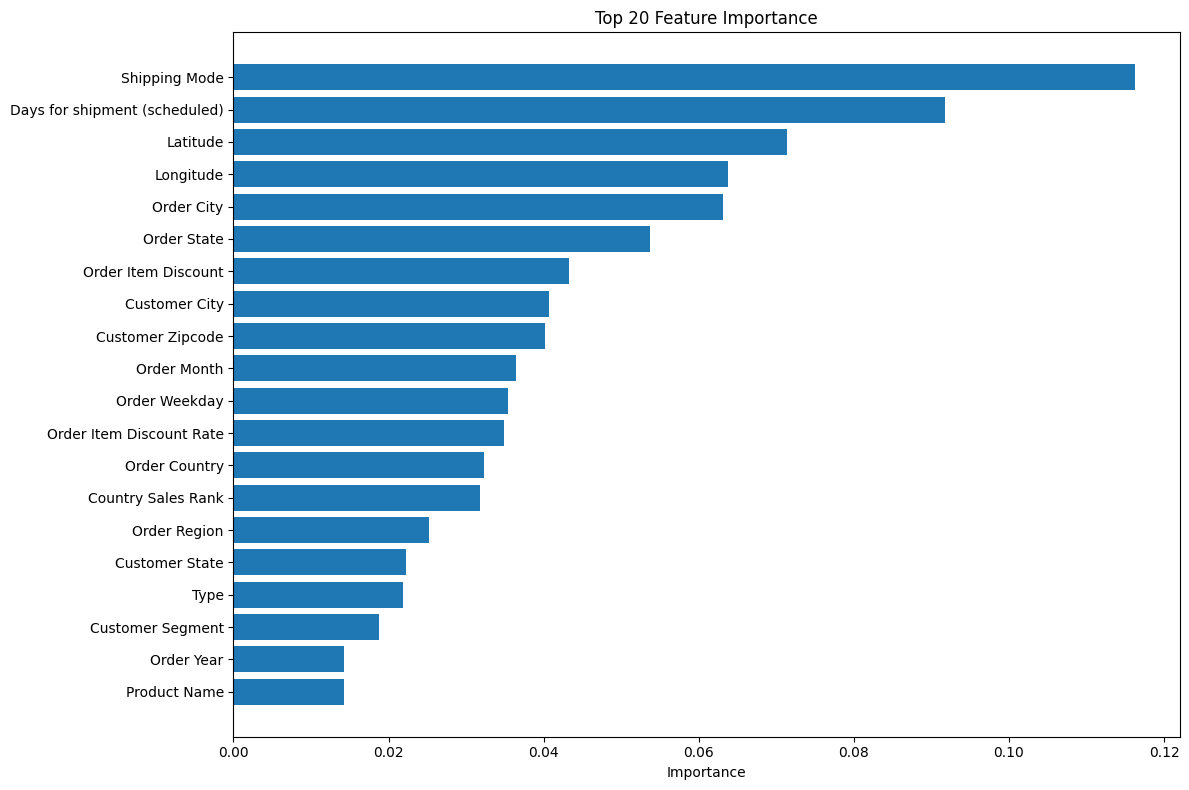

In [52]:
# Feature Importance Analysis


import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train_ml.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*60)
print("TOP 20 IMPORTANT FEATURES")
print("="*60)

display(importance.head(20))

plt.figure(figsize=(12,8))

plt.barh(
    importance.head(20)["Feature"][::-1],
    importance.head(20)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")

plt.tight_layout()
plt.show()

In [53]:
# SHAP Explainable AI

import shap

print("="*60)
print("Initializing SHAP...")
print("="*60)

explainer = shap.TreeExplainer(best_model)

print("SHAP Explainer Ready")

Initializing SHAP...
SHAP Explainer Ready


In [54]:
import shap
import sklearn

print("SHAP Version :", shap.__version__)
print("Scikit-learn :", sklearn.__version__)

SHAP Version : 0.52.0
Scikit-learn : 1.6.1


Calculating Permutation Importance...


,Feature,Importance
26,Shipping Mode,0.103758
0,Type,0.063123
12,Longitude,0.061662
11,Latitude,0.055923
14,Order City,0.051341
21,Order State,0.047486
15,Order Country,0.041633
20,Order Region,0.037706
29,Order Weekday,0.035469
32,Country Sales Rank,0.035462


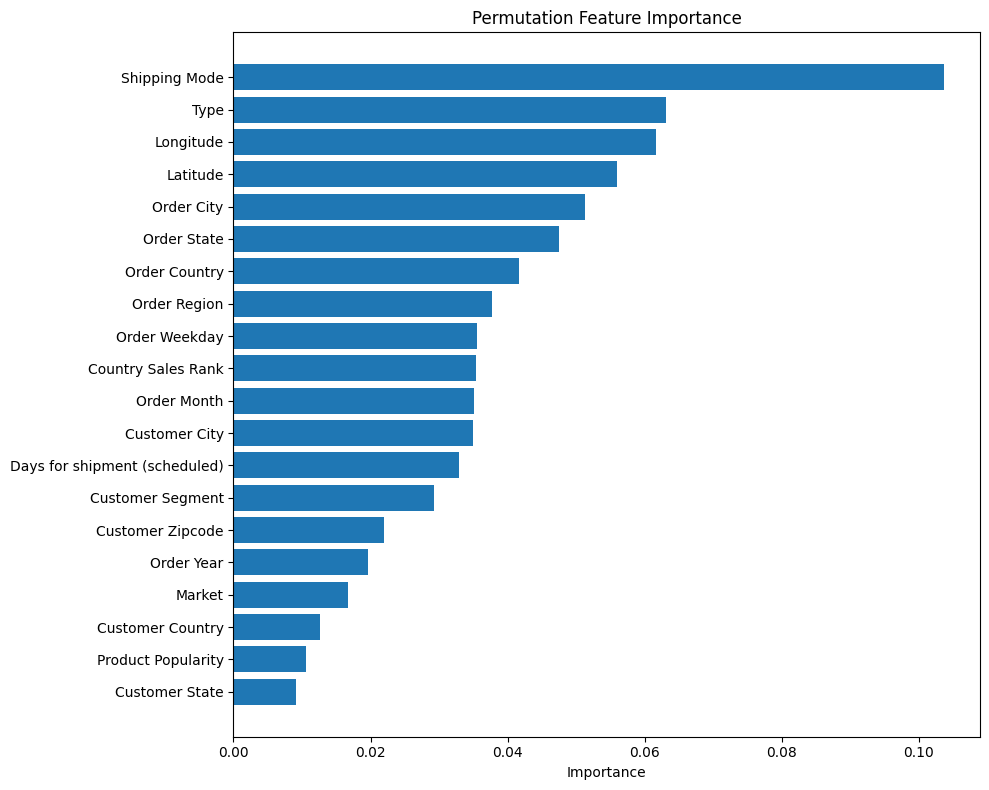

In [56]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print("Calculating Permutation Importance...")

X_small = X_test_ml.sample(300, random_state=42)
y_small = y_test.loc[X_small.index]

result = permutation_importance(
    best_model,
    X_small,
    y_small,
    scoring="f1",
    n_repeats=3,
    random_state=42,
    n_jobs=1          # IMPORTANT: use only one core
)

perm_importance = pd.DataFrame({
    "Feature": X_small.columns,
    "Importance": result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

display(perm_importance.head(20))

plt.figure(figsize=(10,8))
plt.barh(
    perm_importance.head(20)["Feature"][::-1],
    perm_importance.head(20)["Importance"][::-1]
)
plt.title("Permutation Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [57]:
#Customer Intelligence (K-Means Segmentation)

In [58]:
# Customer-Level Dataset

customer_df = (
    df_clean
    .groupby("Customer Id")
    .agg({
        "Sales": "sum",
        "Order Id": "count",
        "Order Profit Per Order": "sum",
        "Late_delivery_risk": "mean"
    })
    .reset_index()
)

customer_df.columns = [
    "Customer Id",
    "Total Sales",
    "Total Orders",
    "Total Profit",
    "Late Delivery Rate"
]

print("="*60)
print("Customer Dataset Created")
print("="*60)

print(customer_df.shape)

customer_df.head()

Customer Dataset Created
(20652, 5)


,Customer Id,Total Sales,Total Orders,Total Profit,Late Delivery Rate
0,1,499.950012,1,159.690002,1.000000
1,2,1819.730034,10,208.739999,0.300000
2,3,3537.680094,18,334.489999,0.000000
3,4,1719.630030,14,-439.979992,0.785714
4,5,1274.750023,7,309.850002,0.714286


In [59]:
# Scale Features
from sklearn.preprocessing import StandardScaler

features = [
    "Total Sales",
    "Total Orders",
    "Total Profit",
    "Late Delivery Rate"
]

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    customer_df[features]
)

print("Customer features standardized.")

Customer features standardized.


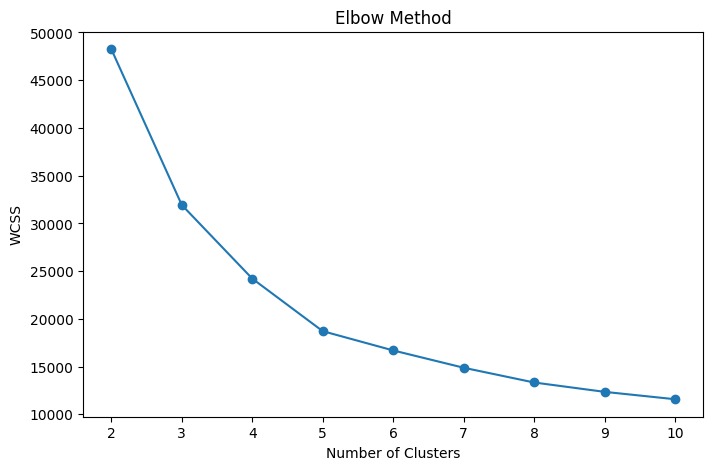

In [60]:
# Find Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_cluster)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [61]:
# Build Customer Personas

In [62]:
# Apply K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(X_cluster)

print("="*60)
print("Customer Clustering Completed")
print("="*60)

customer_df["Cluster"].value_counts().sort_index()

Customer Clustering Completed


,count
Cluster,
0,2692
1,5853
2,5163
3,5001
4,1943


In [63]:
# Cluster Statistics

cluster_summary = (
    customer_df
    .groupby("Cluster")
    .agg({

        "Total Sales":"mean",

        "Total Orders":"mean",

        "Total Profit":"mean",

        "Late Delivery Rate":"mean",

        "Customer Id":"count"

    })
)

cluster_summary.rename(
    columns={"Customer Id":"Customers"},
    inplace=True
)

cluster_summary = cluster_summary.round(2)

display(cluster_summary)

,Total Sales,Total Orders,Total Profit,Late Delivery Rate,Customers
Cluster,,,,,
0,4676.01,22.87,779.15,0.54,2692
1,452.71,1.98,53.10,0.98,5853
2,2477.04,12.63,397.76,0.56,5163
3,499.80,2.21,52.51,0.03,5001
4,3221.20,16.00,-389.91,0.56,1943


In [64]:
# Customer Segments
segment_map = {

    0:"Segment A",

    1:"Segment B",

    2:"Segment C",

    3:"Segment D",

    4:"Segment E"

}

customer_df["Customer Segment AI"] = (
    customer_df["Cluster"]
    .map(segment_map)
)

customer_df.head()

,Customer Id,Total Sales,Total Orders,Total Profit,Late Delivery Rate,Cluster,Customer Segment AI
0,1,499.950012,1,159.690002,1.000000,1,Segment B
1,2,1819.730034,10,208.739999,0.300000,2,Segment C
2,3,3537.680094,18,334.489999,0.000000,2,Segment C
3,4,1719.630030,14,-439.979992,0.785714,4,Segment E
4,5,1274.750023,7,309.850002,0.714286,2,Segment C


In [65]:
# Visualize Clusters
import plotly.express as px

fig = px.scatter(

    customer_df,

    x="Total Sales",

    y="Total Profit",

    color="Customer Segment AI",

    size="Total Orders",

    hover_data=[
        "Customer Id",
        "Late Delivery Rate"
    ],

    title="AI Customer Segmentation"

)

fig.show()

In [66]:
# Rename Segments
# Business Customer Personas

persona_map = {
    0: "VIP Customers",
    1: "High-Risk Customers",
    2: "Loyal Customers",
    3: "New/Stable Customers",
    4: "Loss-Making Customers"
}

customer_df["Customer Persona"] = (
    customer_df["Cluster"].map(persona_map)
)

customer_df.head()

,Customer Id,Total Sales,Total Orders,Total Profit,Late Delivery Rate,Cluster,Customer Segment AI,Customer Persona
0,1,499.950012,1,159.690002,1.000000,1,Segment B,High-Risk Customers
1,2,1819.730034,10,208.739999,0.300000,2,Segment C,Loyal Customers
2,3,3537.680094,18,334.489999,0.000000,2,Segment C,Loyal Customers
3,4,1719.630030,14,-439.979992,0.785714,4,Segment E,Loss-Making Customers
4,5,1274.750023,7,309.850002,0.714286,2,Segment C,Loyal Customers


In [67]:
# Executive Persona Dashboard
import plotly.express as px

persona_summary = (
    customer_df
    .groupby("Customer Persona")
    .agg({
        "Customer Id":"count",
        "Total Sales":"mean",
        "Total Profit":"mean",
        "Late Delivery Rate":"mean"
    })
    .reset_index()
)

persona_summary.rename(
    columns={"Customer Id":"Customers"},
    inplace=True
)

display(persona_summary)

fig = px.bar(
    persona_summary,
    x="Customer Persona",
    y="Customers",
    color="Customer Persona",
    title="Customer Personas Distribution"
)

fig.show()

,Customer Persona,Customers,Total Sales,Total Profit,Late Delivery Rate
0,High-Risk Customers,5853,452.707124,53.102855,0.983598
1,Loss-Making Customers,1943,3221.197483,-389.906442,0.556863
2,Loyal Customers,5163,2477.036335,397.756206,0.557808
3,New/Stable Customers,5001,499.798151,52.508176,0.032121
4,VIP Customers,2692,4676.012020,779.149889,0.539435


In [69]:
# AI Business Recommendations

recommendations = {
    "VIP Customers":
        "Provide premium support, loyalty rewards, and priority shipping.",

    "Loyal Customers":
        "Increase engagement through personalized promotions and cross-selling.",

    "High-Risk Customers":
        "Improve delivery reliability and proactively communicate shipment updates.",

    "New/Stable Customers":
        "Encourage repeat purchases through onboarding offers and targeted campaigns.",

    "Loss-Making Customers":
        "Review pricing, discounts, and fulfillment costs to improve profitability."
}

persona_summary["Recommendation"] = (
    persona_summary["Customer Persona"].map(recommendations)
)

display(persona_summary)

,Customer Persona,Customers,Total Sales,Total Profit,Late Delivery Rate,Recommendation
0,High-Risk Customers,5853,452.707124,53.102855,0.983598,Improve delivery reliability and proactively c...
1,Loss-Making Customers,1943,3221.197483,-389.906442,0.556863,"Review pricing, discounts, and fulfillment cos..."
2,Loyal Customers,5163,2477.036335,397.756206,0.557808,Increase engagement through personalized promo...
3,New/Stable Customers,5001,499.798151,52.508176,0.032121,Encourage repeat purchases through onboarding ...
4,VIP Customers,2692,4676.012020,779.149889,0.539435,"Provide premium support, loyalty rewards, and ..."


In [70]:
# Advanced Customer Intelligence

customer_df["Average Order Value"] = (
    customer_df["Total Sales"] /
    customer_df["Total Orders"]
).round(2)

customer_df["Profit Margin (%)"] = (
    (
        customer_df["Total Profit"] /
        customer_df["Total Sales"]
    ) * 100
).round(2)

customer_df["Delivery Score"] = (
    (1 - customer_df["Late Delivery Rate"]) * 100
).round(2)

customer_df.head()

,Customer Id,Total Sales,Total Orders,Total Profit,Late Delivery Rate,Cluster,Customer Segment AI,Customer Persona,Average Order Value,Profit Margin (%),Delivery Score
0,1,499.950012,1,159.690002,1.000000,1,Segment B,High-Risk Customers,499.95,31.94,0.00
1,2,1819.730034,10,208.739999,0.300000,2,Segment C,Loyal Customers,181.97,11.47,70.00
2,3,3537.680094,18,334.489999,0.000000,2,Segment C,Loyal Customers,196.54,9.46,100.00
3,4,1719.630030,14,-439.979992,0.785714,4,Segment E,Loss-Making Customers,122.83,-25.59,21.43
4,5,1274.750023,7,309.850002,0.714286,2,Segment C,Loyal Customers,182.11,24.31,28.57


In [71]:
# Executive Customer Dashboard
import plotly.express as px

fig = px.scatter(

    customer_df,

    x="Average Order Value",

    y="Profit Margin (%)",

    color="Customer Persona",

    size="Total Orders",

    hover_data=[
        "Customer Id",
        "Total Sales",
        "Delivery Score"
    ],

    title="Customer Profitability Matrix"

)

fig.show()

In [72]:
# Customer Health Score

customer_df["Customer Health Score"] = (

      customer_df["Profit Margin (%)"] * 0.40

    + customer_df["Delivery Score"] * 0.35

    + (
        customer_df["Total Orders"] /
        customer_df["Total Orders"].max()
      ) * 25

).round(2)

customer_df.head()

,Customer Id,Total Sales,Total Orders,Total Profit,Late Delivery Rate,Cluster,Customer Segment AI,Customer Persona,Average Order Value,Profit Margin (%),Delivery Score,Customer Health Score
0,1,499.950012,1,159.690002,1.000000,1,Segment B,High-Risk Customers,499.95,31.94,0.00,13.31
1,2,1819.730034,10,208.739999,0.300000,2,Segment C,Loyal Customers,181.97,11.47,70.00,34.41
2,3,3537.680094,18,334.489999,0.000000,2,Segment C,Loyal Customers,196.54,9.46,100.00,48.36
3,4,1719.630030,14,-439.979992,0.785714,4,Segment E,Loss-Making Customers,122.83,-25.59,21.43,4.71
4,5,1274.750023,7,309.850002,0.714286,2,Segment C,Loyal Customers,182.11,24.31,28.57,23.45


In [73]:
# Customer Health Categories
customer_df["Customer Health"] = pd.cut(

    customer_df["Customer Health Score"],

    bins=[-100,40,70,100],

    labels=[

        "Needs Attention",

        "Healthy",

        "Excellent"

    ]

)

customer_df["Customer Health"].value_counts()

,count
Customer Health,
Needs Attention,16258
Healthy,4391
Excellent,0


In [83]:
customer_df["Customer Health"] = pd.qcut(
    customer_df["Customer Health Score"],
    q=3,
    labels=[
        "Needs Attention",
        "Healthy",
        "Excellent"
    ]
)

customer_df["Customer Health"].value_counts()

,count
Customer Health,
Needs Attention,6885
Healthy,6885
Excellent,6882
